Task 1 (20 points) For the Titanic challenge (https://www.kaggle.com/c/titanic), we need to
guess whether the individuals from the test dataset had survived or not. Please:

1) Preprocess your Titanic training data;

In [3]:
import pandas as pd
import numpy as np

# Loading dataset
df = pd.read_csv("/content/train.csv")

# Getting title from the Name column
def get_title(name):
    return name.split(",")[1].split(".")[0].strip()

df["Title"] = df["Name"].apply(get_title)

# merging small/rare titles
rare_titles = ["Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major",
               "Rev", "Sir", "Jonkheer", "Dona"]
df["Title"] = df["Title"].replace({
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
})
df["Title"] = df["Title"].replace(dict.fromkeys(rare_titles, "Rare"))

title_map = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
df["Title"] = df["Title"].map(title_map).fillna(5).astype(int)

# Mapping Sex feature
df["Sex"] = df["Sex"].map({"male": 0, "female": 1}).astype(int)

# Embarked feature filling missing values and encoding
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
embarked_map = {"S": 0, "C": 1, "Q": 2}
df["Embarked"] = df["Embarked"].map(embarked_map).astype(int)

# Fare - filling missing with median
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

# For Age filling missing using median per Title
age_median_by_title = df.groupby("Title")["Age"].transform(lambda s: s.fillna(s.median()))
df["Age"] = age_median_by_title

# Family features
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

#Dropping columns we not want in the model
df_model = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

#Final X, y
X = df_model.drop(columns=["Survived"])
y = df_model["Survived"]
print("Features:", list(X.columns))
print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()


Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone']
X shape: (891, 10)
y shape: (891,)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone
0,3,0,22.0,1,0,7.2500,0,1,2,0
1,1,1,38.0,1,0,71.2833,1,3,2,0
2,3,1,26.0,0,0,7.9250,0,2,1,1
3,1,1,35.0,1,0,53.1000,0,3,2,0
4,3,0,35.0,0,0,8.0500,0,1,1,1


2) (5 points ) Learn and fine-tune a decision tree model with the Titanic training data, plot
your decision tree;

Decision Tree Accuracy: 0.832

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.83      0.83      0.83       179


Confusion Matrix:
 [[92 13]
 [17 57]]


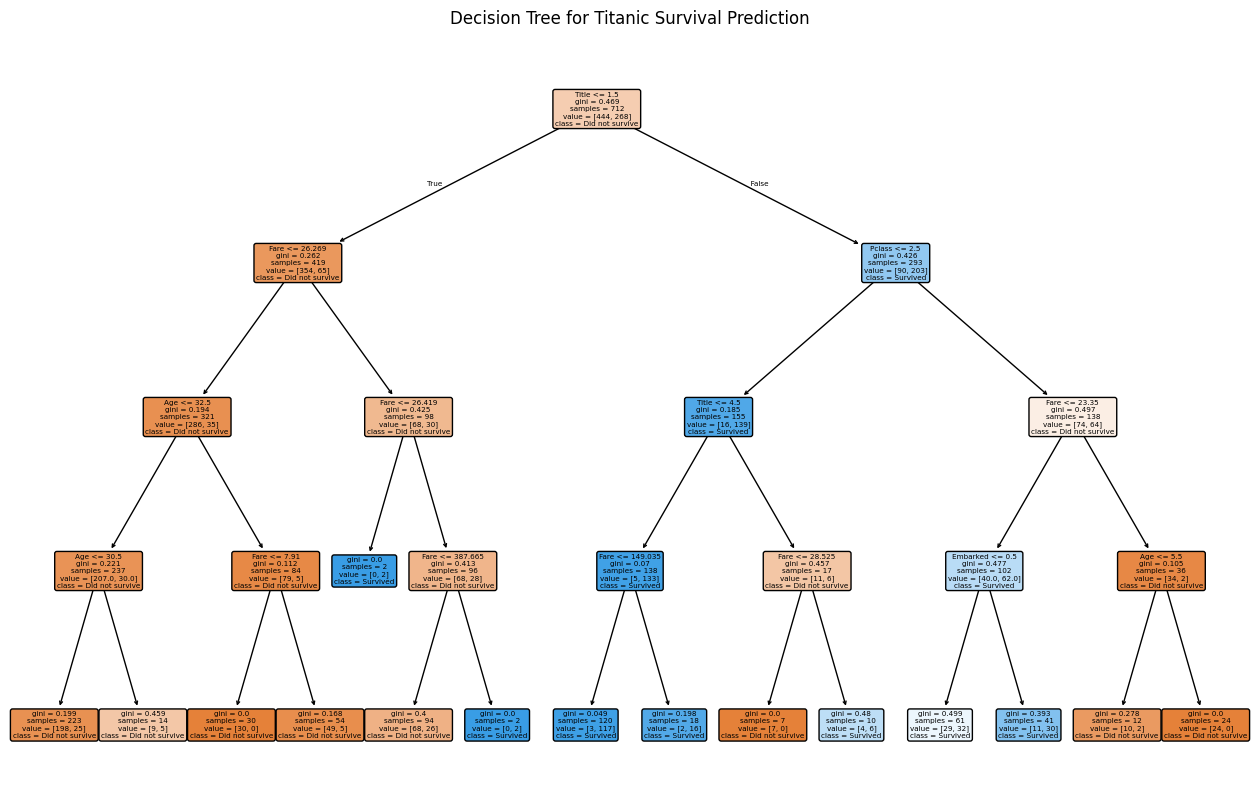

In [4]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Splitting into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the Decision Tree
dt = DecisionTreeClassifier(
    criterion='gini',   #entropy
    max_depth=4,
    random_state=42
)
dt.fit(X_train, y_train)

# Evaluating performance
y_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Visualizing the tree
plt.figure(figsize=(16, 10))
plot_tree(
    dt,
    filled=True,
    rounded=True,
    feature_names=X.columns,
    class_names=["Did not survive", "Survived"]
)
plt.title("Decision Tree for Titanic Survival Prediction")
plt.show()


3) (5 points) Apply the five-fold cross validation of your fine-tuned decision tree learning
model to the Titanic training data to extract average classification accuracy;

In [6]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(dt, X, y, cv=5, scoring='accuracy')

print("Cross-Validation Scores for each fold:", np.round(cv_scores, 3))
print("Average Accuracy:", round(np.mean(cv_scores), 3))
print("Standard Deviation:", round(np.std(cv_scores), 3))

Cross-Validation Scores for each fold: [0.838 0.82  0.831 0.781 0.843]
Average Accuracy: 0.823
Standard Deviation: 0.022


4. (5 points) Apply the five-fold cross validation of your fine-tuned random forest learning
model to the Titanic training data to extract average classification accuracy;

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Defining the Random Forest model and number of trees in the forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42
)

# Perform 5-fold cross-validation
rf_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

print("Cross-Validation Scores for each fold:", np.round(rf_scores, 3))
print("Average Accuracy:", round(np.mean(rf_scores), 3))
print("Standard Deviation:", round(np.std(rf_scores), 3))


Cross-Validation Scores for each fold: [0.838 0.809 0.831 0.798 0.837]
Average Accuracy: 0.823
Standard Deviation: 0.016


5) (5 points) Which algorithm is better, Decision Tree or Random Forest? What are your
observations and conclusions from the algorithm comparison and analysis?

After completing both models, I compared the single Decision Tree and the Random Forest using five-fold cross-validation.
 The Decision Tree achieved an average accuracy of 0.823 (std = 0.022), while the Random Forest achieved 0.823 (std = 0.016).
 Even though the mean accuracy was nearly identical, the Random Forest showed slightly lower variance across folds, confirming that ensembling improves model stability.
 From a practical standpoint:
The Decision Tree is easier to interpret and explain, making it ideal when transparency is important (e.g., explaining survival factors).
The Random Forest is preferable for deployment if the goal is more consistent, reliable predictions.
The Conclusion is both models performed well, but the Random Forest offers a modest edge in stability, while the Decision Tree provides better interpretability.
